# Práctica Minería de Datos

**Este documento contiene la parte práctica de la tarea de evaluación del módulo de Minería de Datos.** 

**La idea es que vayas avanzando en el documento y completando códigos (asegurando ejecutar para que se vean las salidas) y preguntas asociadas.**

**Una vez terminado, lo guardas con el nombre "PracticaMineria_NombreApellido.ipynb". Descargalo también con el mismo nombre pero en extensión HTML y adjunta ambos archivos a la entrega.** 

**A disfrutar del proceso!**

## Pregunta 1

Indica en el siguiente chunk el código necesario para importar el conjunto de datos **"FEV_data.csv"** y muestra la información del archivo. 

Información sobre el archivo aquí: 
https://view.officeapps.live.com/op/view.aspx?src=http%3A%2F%2Fwww.emersonstatistics.com%2Fdatasets%2Ffev.doc&wdOrigin=BROWSELINK

In [67]:
import pandas as pd

# Lectura del archivo

df = pd.read_csv(r'C:\Users\luissinho1999\Downloads\FEV_data.csv')

# Información

print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   seqnbr  654 non-null    int64  
 1   subjid  654 non-null    int64  
 2   age     654 non-null    int64  
 3   fev     654 non-null    float64
 4   height  654 non-null    float64
 5   sex     654 non-null    int64  
 6   smoke   654 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 35.9 KB
None
   seqnbr  subjid  age    fev  height  sex  smoke
0       1     301    9  1.708    57.0    2      2
1       2     451    8  1.724    67.5    2      2
2       3     501    7  1.720    54.5    2      2
3       4     642    9  1.558    53.0    1      2
4       5     901    9  1.895    57.0    1      2


¿Cuantos registros y variables tiene el archivo? 

**Respuesta**:

Registros = 654

Variables = 7 (No todas son válidas como predictores en modelo, las válidas son un total de 5)

¿Tienen las variables el tipo correcto en relación a su lógica naturaleza?

**Respuesta**: Hay que cambiar sex y smoke de número entero a categórico:


In [68]:
# Corrección de tipos en caso de necesidad
df['sex'] = df['sex'].astype('category')
df['smoke'] = df['smoke'].astype('category')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   seqnbr  654 non-null    int64   
 1   subjid  654 non-null    int64   
 2   age     654 non-null    int64   
 3   fev     654 non-null    float64 
 4   height  654 non-null    float64 
 5   sex     654 non-null    category
 6   smoke   654 non-null    category
dtypes: category(2), float64(2), int64(3)
memory usage: 27.2 KB
None


En cuanto al rol de las variables, ¿son todas válidas como predictores en modelo? 

**Respuesta**: No, seqnbr y subjid no son válidas, ya que solo contienen información de cada niño y podrían ser utilizadas como indices.


In [69]:
# Eliminación de variables por rol en caso de necesidad

df.drop(['seqnbr', 'subjid'], axis=1, inplace=True)

## Pregunta 2

Sabiendo que la variable objetivo es *Fev*. Presenta un gráfico con las relaciones de asociación de los predictores frente a Fev. 

In [71]:
# Librería estadística!
import scipy.stats as stats

varObj=df.fev
imputFev = df.drop(['fev'],axis=1)
varObj.describe()
# Gráfico de relaciones con la objetivo


def cramers_v(var1, varObj):
    if not var1.dtypes.name == 'category':
        var1 = pd.cut(var1, bins = 5)
    if not varObj.dtypes.name == 'category':
        varObj = pd.cut(varObj, bins = 5)
        
    data = pd.crosstab(var1, varObj).values
    vCramer = stats.contingency.association(data, method = 'cramer')
    return vCramer

tablaCramer = pd.DataFrame(imputFev.apply(lambda x: cramers_v(x,varObj)),columns=['VCramer'])

import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relaciones frente al fev').update_yaxes(categoryorder="total ascending")


¿Cuales son las 3 variables que elegirías para tu primer modelo de regresión en base a esta información?

**Respuesta**: height, age y sex


## Pregunta 3

Ajusta el modelo de regresión que contiene los 3 predictores que has decidido en el apartado anterior en el propio conjunto de entrenamiento (no hace falta hacer partición) y muestra el summary de dicho modelo. 

In [72]:
# Ajuste de modelo 
import statsmodels.api as sm

# Selección de las variables predictoras y la variable objetivo
predictores = ['height', 'age', 'sex']
objetivo = 'fev'

# Añadir una constante al conjunto de datos para el intercepto
X = sm.add_constant(df[predictores])
y = df[objetivo]

# Ajustar el modelo de regresión
modelo = sm.OLS(y, X).fit()


# Summary
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    fev   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     744.6
Date:                Mon, 11 Mar 2024   Prob (F-statistic):          9.05e-210
Time:                        06:25:27   Log-Likelihood:                -346.99
No. Observations:                 654   AIC:                             702.0
Df Residuals:                     650   BIC:                             719.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1263      0.242    -17.058      0.0

 A la vista de los valores de ajuste, ¿qué porcentaje de variabilidad explicada tiene el modelo? Interpreta el parámetro estimado de la *altura*.

**Respuesta**: A) Tiene un 77,4% de variabilidad explicada este modelo. B) Por cada pulgada adicional de altura, se espera un aumento de 0.1046 litros por segundo en la variable FEV, suponiendo que el resto de predictores no varían.

## Pregunta 4

Aplica validación cruzada repetida para tu modelo con nuestra querida función *cross_val_lin* y una semilla conformada por los 4 últimos dígitos de tu documento de identidad. Muestra el boxplot de sesgo-varianza de las estimaciones. 

Modelo: fev ~ height + age + sex
Coeficiente de determinación R2: 0.768 (0.034)


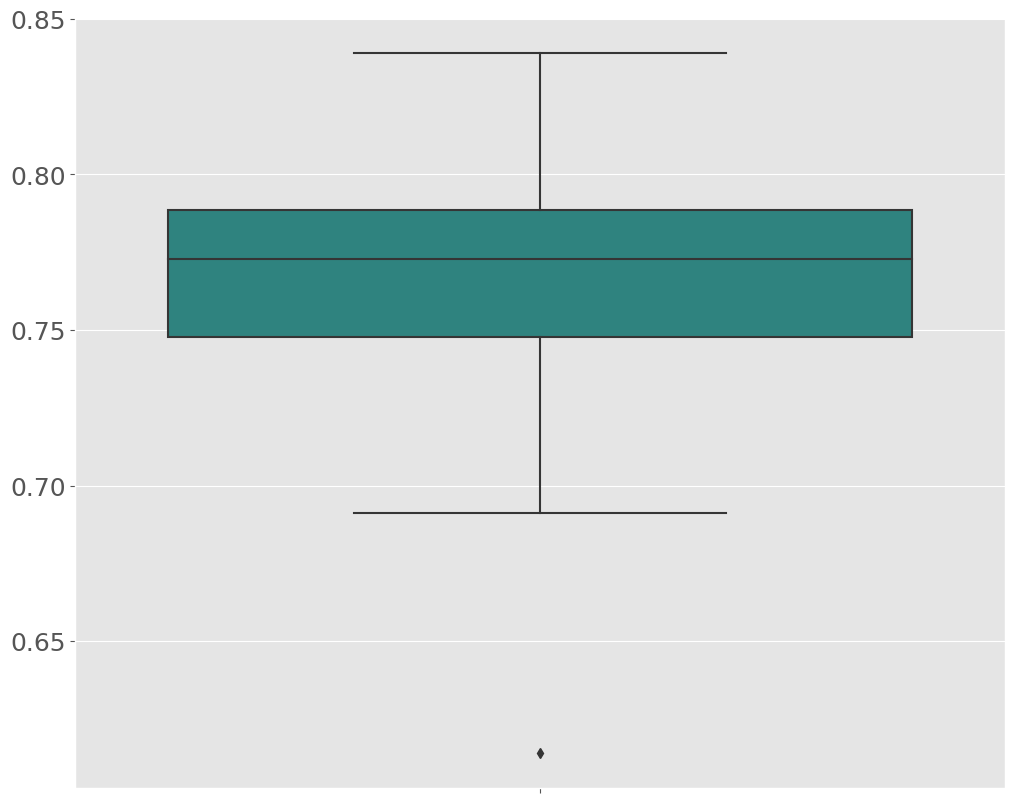

In [73]:
import numpy as np
import seaborn as sns
import patsy
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


# Validación cruzada
# Función para comparación por validación cruzada
def cross_val_lin(formula, data, seed=3818):
    # Generamos las matrices de diseño según la fórmula de modelo completo
    y, X = patsy.dmatrices(formula, data, return_type='dataframe')

    model = LinearRegression()

    # Establecemos esquema de validación fijando random_state (reproducibilidad)
    cv = RepeatedKFold(n_splits=5, n_repeats=20, random_state=seed)

    # Obtenemos los resultados de R2 para cada partición tr-tst
    scores = cross_val_score(model, X, y, cv=cv)

    # Sesgo y varianza
    print('Modelo: ' + formula)
    print('Coeficiente de determinación R2: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))
    
    # Boxplot sesgo-varianza
    sns.boxplot(y=scores, palette='viridis')
    plt.show()

    return scores

    

resultados_cross_val = cross_val_lin('fev ~ height + age + sex', df)

     

A la vista de los resultados. ¿Está sobreajustando tu modelo al conjunto de entrenamiento?

**Respuesta** No, por que R2 es muy próximo a nuestro modelo de entrenamiento, y no hay gran variabilidad en los resultados de validación cruzada. Aunque exista un outlier donde el rendimiento de nuestro modelo baje a 0,6 no es preocupante y podemos decir que nuestro modelo es robusto y funciona correctamente.

## Pregunta 5

Indica el código necesario para leer el conjunto de datos **"IPI_Esp.xlsx"** y muestra su cabeza.

In [74]:
# Lectura de datos IPI
IPI = pd.read_excel(r'C:\Users\luissinho1999\Downloads\IPI_Esp.xlsx')
# Primeras filas
print(IPI.head())

          Date  IPI Nacional
0      1975M01        70.658
1      1975M02        72.180
2      1975M03        75.732
3      1975M04        74.844
4      1975M05        74.210


## Pregunta 6

Convierte el conjunto en una serie temporal legible para Python y representa gráficamente la evolución. 

In [75]:
# Conversión a serie temporal legible
IPI['Date'] = IPI['Date'].astype(str)
IPI['Date'] = IPI['Date'].str.replace('M', '-')
print(IPI.head())


          Date  IPI Nacional
0      1975-01        70.658
1      1975-02        72.180
2      1975-03        75.732
3      1975-04        74.844
4      1975-05        74.210


In [11]:
# Convertir en date-time
IPI['Date'] = pd.to_datetime(IPI['Date'], format='mixed')


In [76]:
# Mostrar valores de serie
print(IPI['Date'])

0          1975-01
1          1975-02
2          1975-03
3          1975-04
4          1975-05
          ...     
534        2019-07
535        2019-08
536        2019-09
537        2019-10
538        2019-11
Name: Date, Length: 539, dtype: object


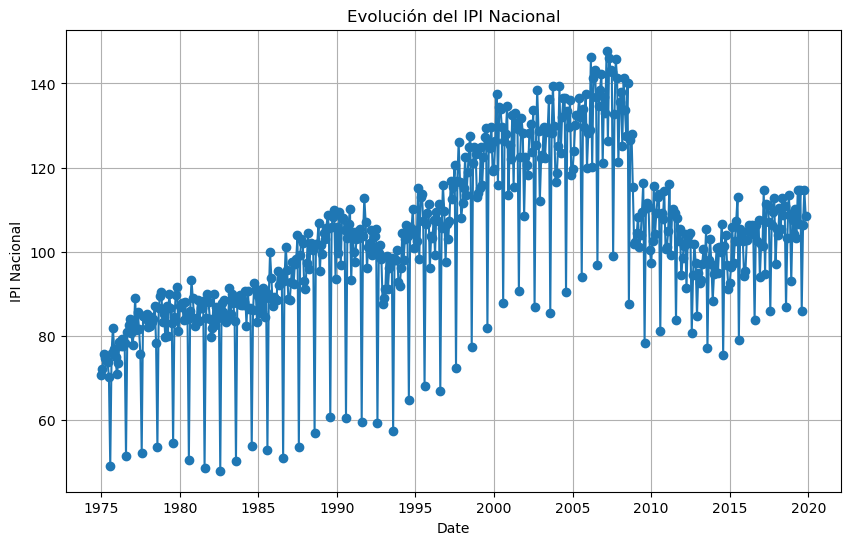

In [13]:
# Gráfico de evolución del IPI
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(IPI['Date'], IPI['IPI Nacional'], marker='o', linestyle='-')
plt.title('Evolución del IPI Nacional')
plt.xlabel('Date')
plt.ylabel('IPI Nacional')
plt.grid(True)
plt.show()
IPI = IPI.loc[:, ~IPI.columns.duplicated()]


¿Qué componentes de la serie se pueden intuir en el gráfico?

**Respuesta**:  
Tendencia: Ascendente.
Estacionalidad: Un valor anual muy por debajo del resto del año.
Ciclo: Con el tiempo hay una crisis (1993 y 2008) que provoca que caigan los niveles significativamente y posteriormente sigue con la tendencia ascendente.
Ruido: Hay un ruido irregular.

## Pregunta 7

Toma una partición con ventana de entrenamiento (todo el histórico hasta diciembre de 2017) y prueba (2018 y 2019). Ajusta el modelo de suavizado que consideres más adecuado a la luz de las características de la serie. Evalua el modelo en términos de error y adecuación de los residuos. ¿El modelo satisface las condiciones residuales en cuanto a  autocorrelaciones?

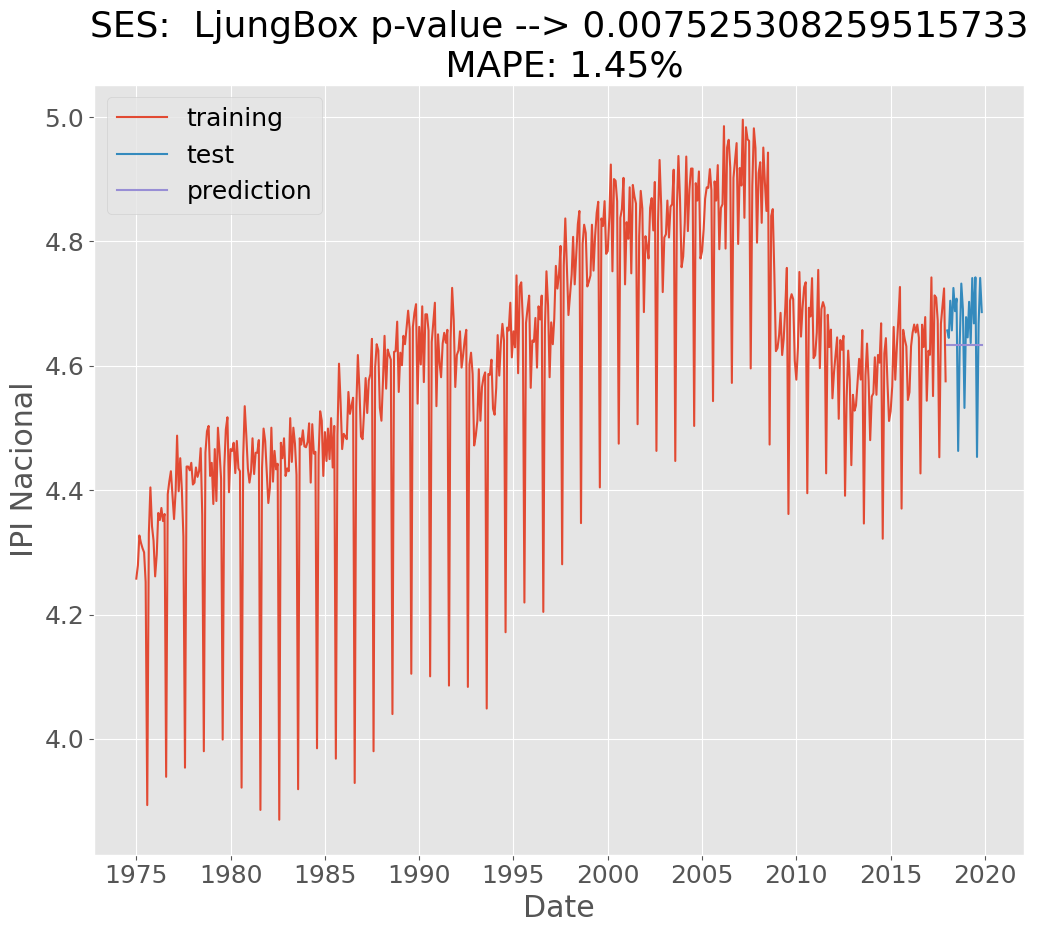

0.007525308259515733
                              Holt Model Results                              
Dep. Variable:           IPI Nacional   No. Observations:                  516
Model:                           Holt   SSE                             10.046
Optimized:                       True   AIC                          -2024.481
Trend:                       Additive   BIC                          -2007.496
Seasonal:                        None   AICC                         -2024.316
Seasonal Periods:                None   Date:                 Mon, 11 Mar 2024
Box-Cox:                        False   Time:                         06:25:57
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.0908029                alpha                 True
smoothing_trend            0.09

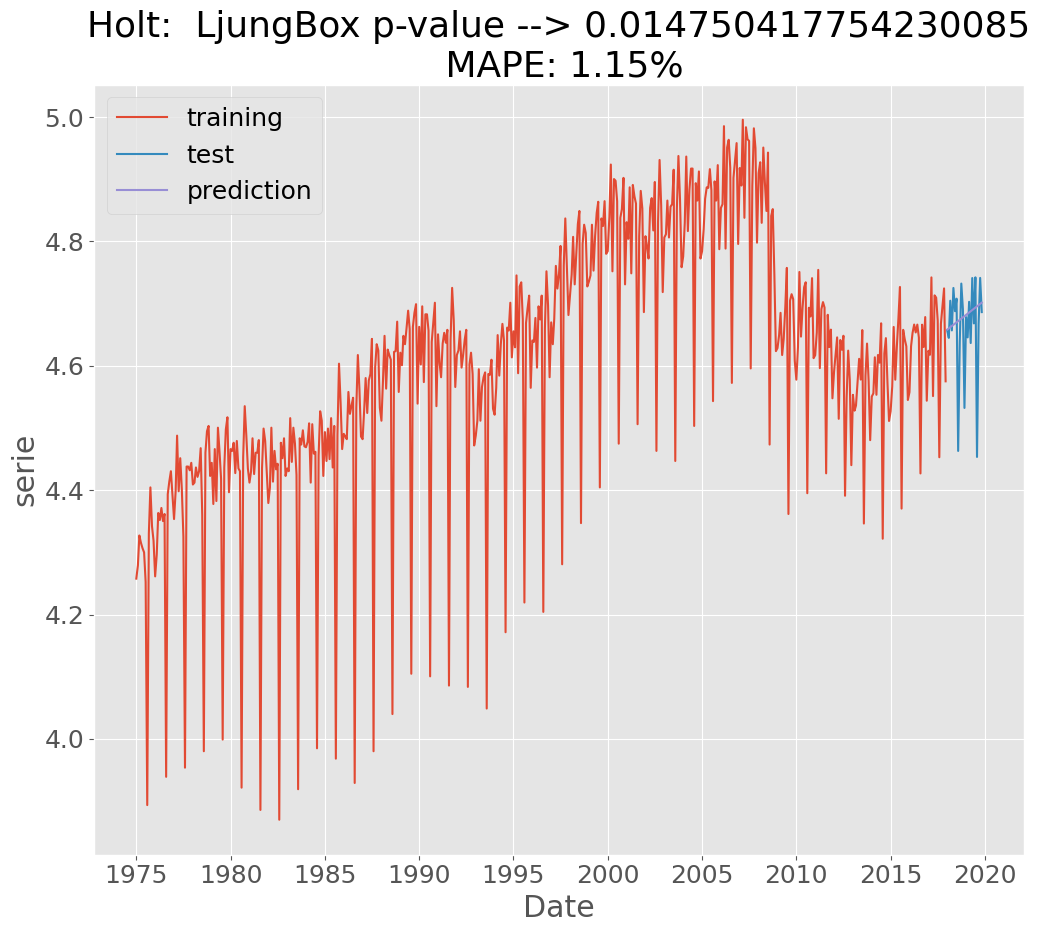

0.014750417754230085
                       ExponentialSmoothing Model Results                       
Dep. Variable:             IPI Nacional   No. Observations:                  516
Model:             ExponentialSmoothing   SSE                              0.809
Optimized:                         True   AIC                          -3300.552
Trend:                         Additive   BIC                          -3232.614
Seasonal:                      Additive   AICC                         -3299.175
Seasonal Periods:                    12   Date:                 Mon, 11 Mar 2024
Box-Cox:                          False   Time:                         06:25:58
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2628701                alpha                 True
smoo

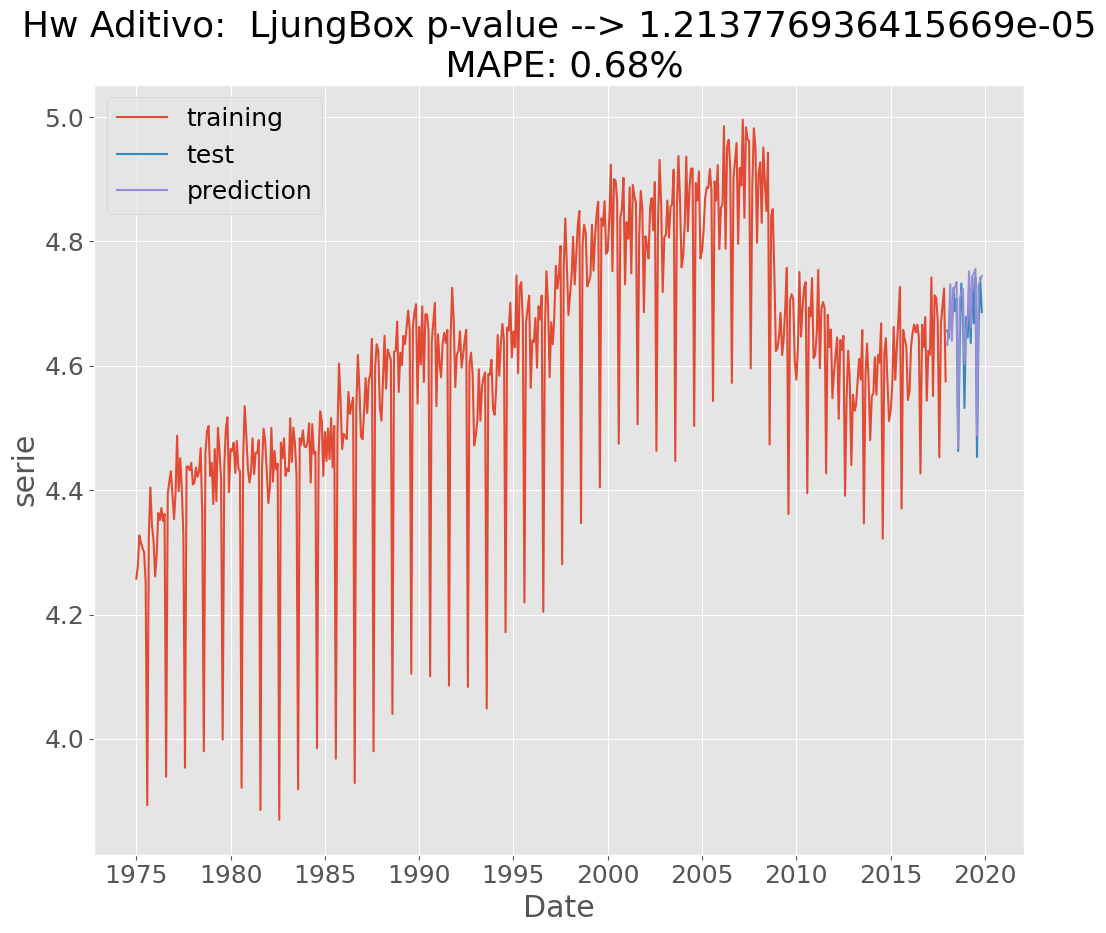

1.213776936415669e-05


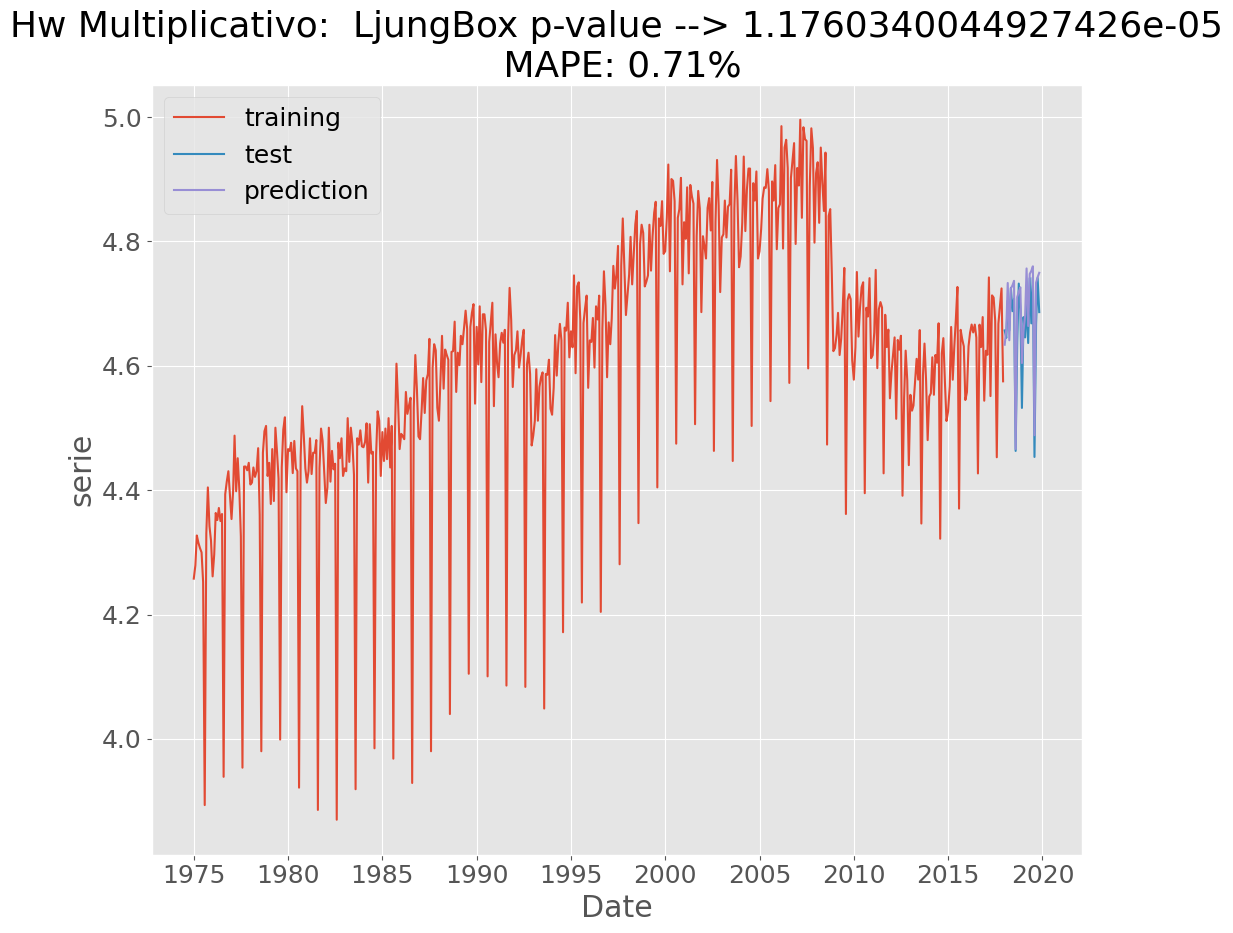

1.1760340044927426e-05


In [77]:
# Partición de datos
from sklearn.model_selection import train_test_split



IPI['Date'] = pd.to_datetime(IPI['Date'])


IPI_train = IPI[IPI['Date'] <= pd.to_datetime('2017-12-31')]
IPI_test = IPI[(IPI['Date'] >= pd.to_datetime('2018-01-01')) & (IPI['Date'] <= pd.to_datetime('2019-12-31'))]

# Ajuste de modelo de suavizado
import statsmodels.tsa.holtwinters as ets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
IPILog = IPI.copy()
IPILog['Date'] = pd.to_datetime(IPILog['Date'])
IPILog.set_index('Date', inplace=True)
IPILog['IPI Nacional'] = np.log(IPILog['IPI Nacional'])
IPI_train = IPILog[:'2017-12-31']
IPI_test = IPILog['2018-01-01':]
IPI_test
def eval_model(model,tr,tst,name='Model',lags=12,serie='serie'):
    lb = np.mean(sm.stats.acorr_ljungbox(model.resid, lags=lags, return_df=True).lb_pvalue)
    pred = model.forecast(steps=len(tst))
    fig1, ax = plt.subplots()
    ax.plot(tr, label='training')
    ax.plot(tst, label='test')
    ax.plot(pred, label='prediction')
    plt.legend(loc='upper left')
    tit = name + ":  LjungBox p-value --> " + str(lb) + "\n MAPE: " + str(round(mean_absolute_percentage_error(tst, pred)*100,2)) + "%"
    plt.title(tit)
    plt.ylabel(serie)
    plt.xlabel('Date')
    plt.show()
    print(lb)

ses = ets.SimpleExpSmoothing(IPI_train).fit()

ses.summary()
eval_model(ses,IPI_train,IPI_test,'SES',serie='IPI Nacional')
# Suavizado de Holt
holt = ets.Holt(IPI_train).fit()
print(holt.summary())

eval_model(holt,IPI_train,IPI_test,'Holt')

hw_add = ets.ExponentialSmoothing(IPI_train,trend='add', damped_trend=False, seasonal='add').fit()
print(hw_add.summary())

eval_model(hw_add,IPI_train,IPI_test,'Hw Aditivo')

hw_mul = ets.ExponentialSmoothing(IPI_train,trend='mul', damped_trend=False, seasonal='mul').fit()
hw_mul.summary()

eval_model(hw_mul,IPI_train,IPI_test,'Hw Multiplicativo')

**Respuesta**: El modelo que me parece mejor e sHolt winters aditivo porque nos proporciona el menor error, por otra parte tiene un p valor de LjungBox mas bajo y muy cercano de cero, es decir, muy mala adecuación de los residuos mostrando patrones sistemáticos, por lo tanto el modelo no satisface las condiciones residuales en cuanto a autocorrelaciones, igualmente me parece el mas idoneo por que ningún modelo adecua correctamente los residuos.


## Pregunta 8

Presenta los correlogramas simple y parcial de la serie diferenciada en lo regular y estacional para el conjunto de entrenamiento. 

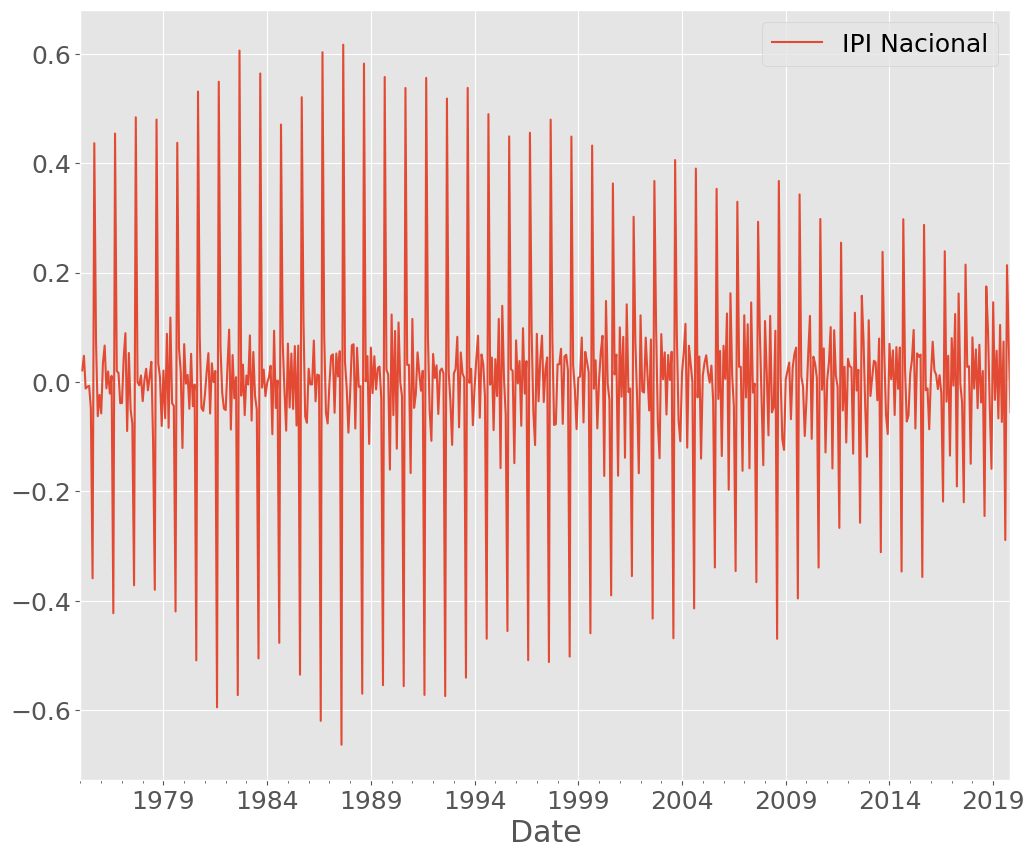

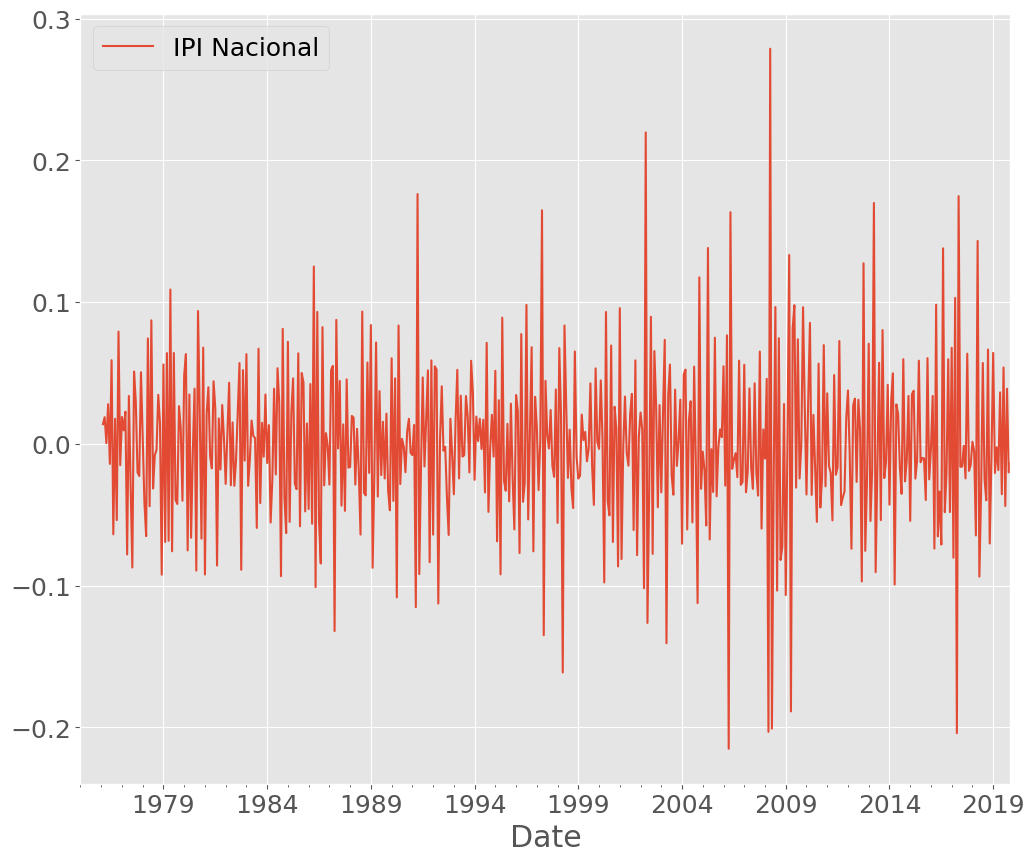

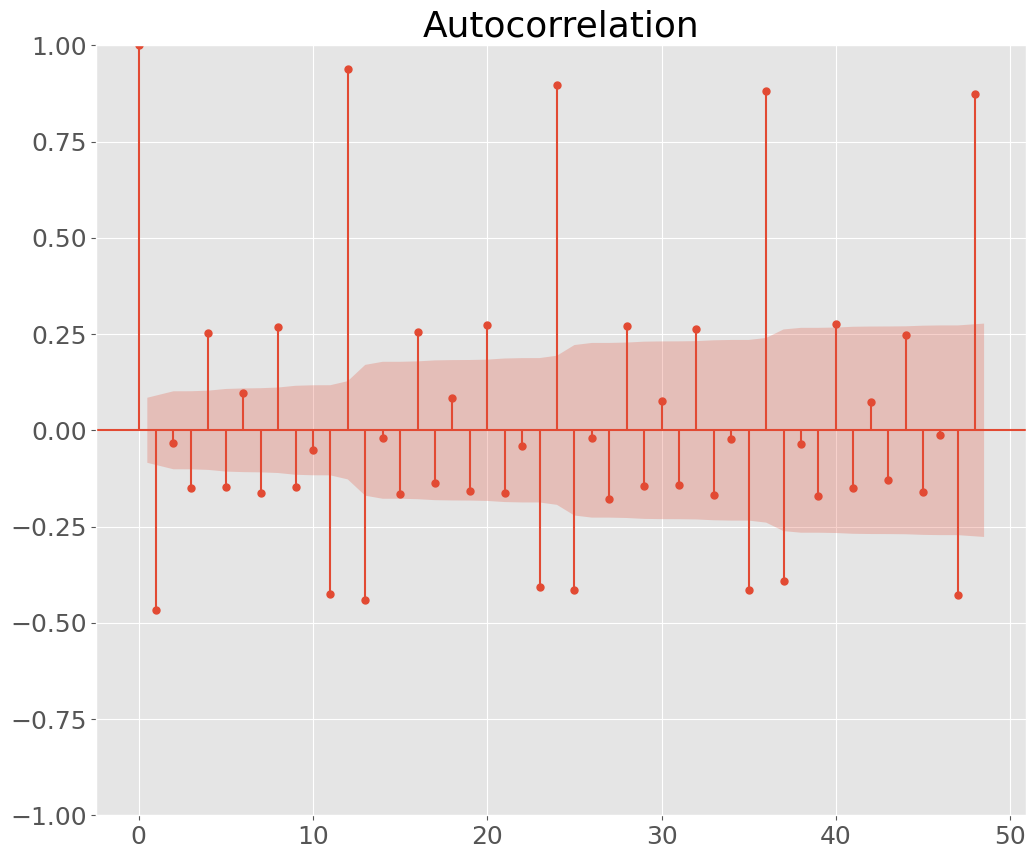

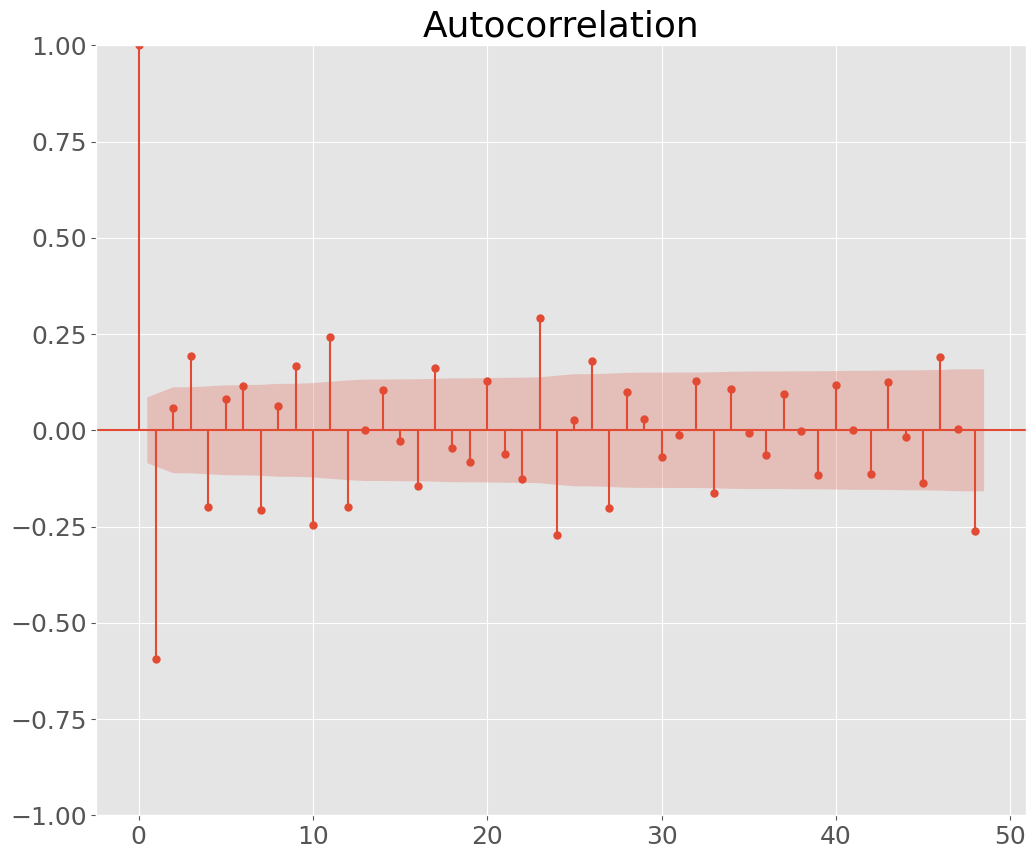

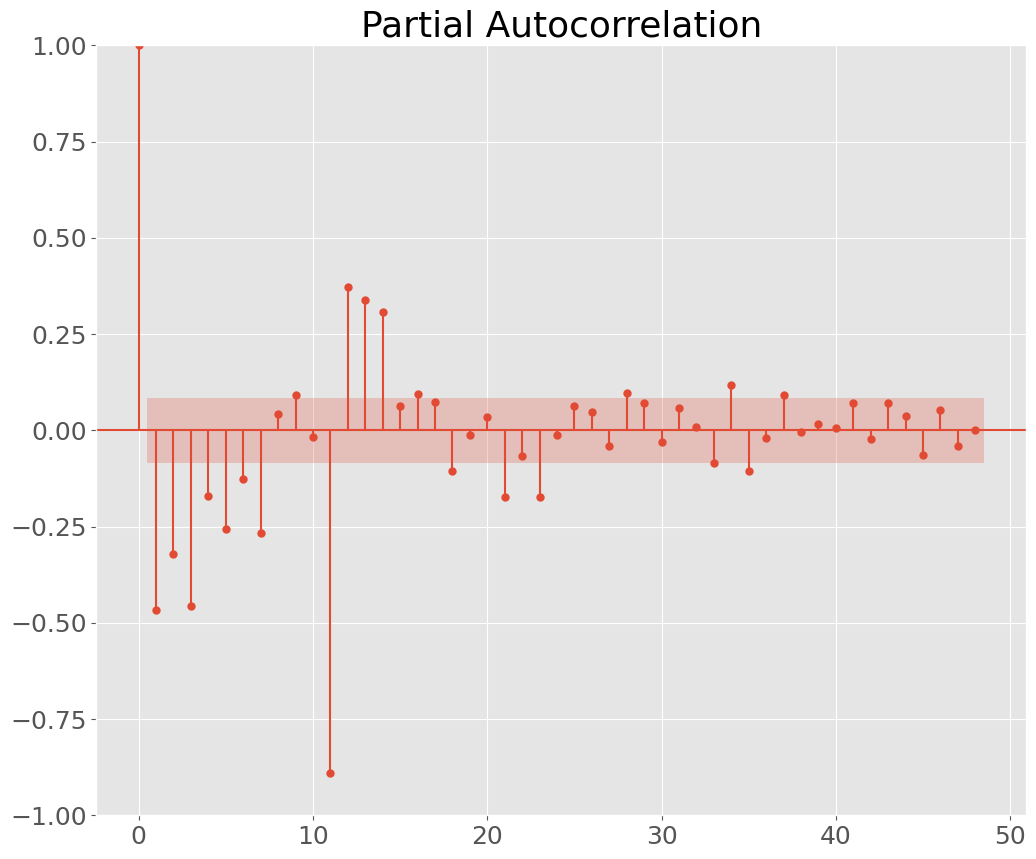

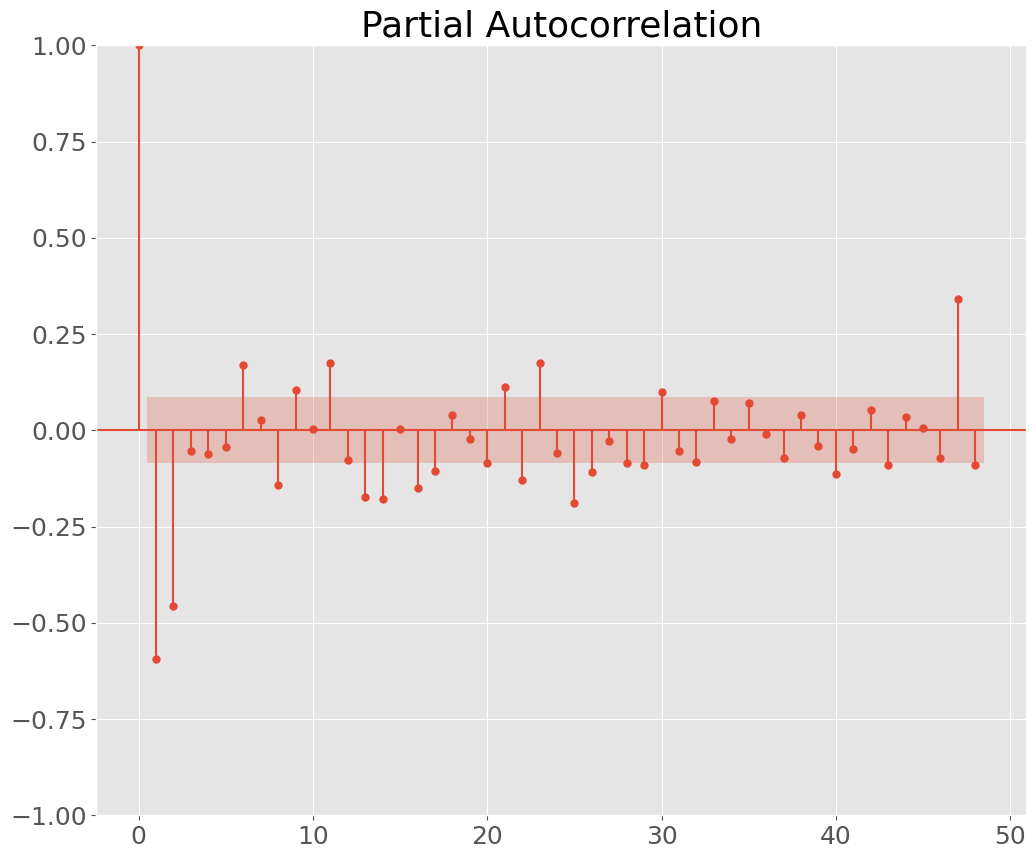

In [78]:
# Diferenciar serie
#Diferenciación regular
IPILog_diff_1 = IPILog.diff(periods=1)
IPILog_diff_1.plot()
plt.show()

#Diferenciación estacional
IPILog_diff_1_12 = IPILog_diff_1.diff(periods=12)
IPILog_diff_1_12.plot()
plt.show()

# Correlograma simple ACF
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(IPILog_diff_1.dropna(inplace=False),lags=48)
plt.show()
plot_acf(IPILog_diff_1_12.dropna(inplace=False),lags=48)
plt.show()
# Correlograma parcial PACF
plot_pacf(IPILog_diff_1.dropna(inplace=False),lags=48,method='ywm')
plt.show()
plot_pacf(IPILog_diff_1_12.dropna(inplace=False),lags=48,method='ywm')
plt.show()



A pesar de la dificultad, intentemos proponer algunos órdenes en lo regular y estacional para un tentativo modelo arima. 

¿Cual sería tu primer modelo a probar según lo que observas en la desaparición de las correlaciones con los retardos?

**Respuesta**: Mi modelo sería ARIMA(2,1,3)(0,0,3) a simple vista viendo ACF y PACF regulares y estacionarios
Aunque importandome pmdarina puedo decir que el modelo arima óptimo es  (2, 1, 3) (2,0,1)


## Pregunta 9

Ajusta ese modelo que propones y evalúa su capacidad de ajuste en test y la adecuación de residuos. 

In [79]:
# Ajustar el modelo ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_percentage_error

train = IPILog['IPI Nacional'][:int(0.8*(len(df)))]
test = IPILog['IPI Nacional'][int(0.8*(len(df))):]


model = SARIMAX(train, order=(2,1,3), seasonal_order=(0,0,3,12))
model_fit = model.fit(disp=False)

# Summary del modelo 

print(model_fit.summary())





                                     SARIMAX Results                                      
Dep. Variable:                       IPI Nacional   No. Observations:                  523
Model:             SARIMAX(2, 1, 3)x(0, 0, 3, 12)   Log Likelihood                 721.865
Date:                            Mon, 11 Mar 2024   AIC                          -1425.730
Time:                                    06:29:12   BIC                          -1387.411
Sample:                                01-01-1975   HQIC                         -1410.722
                                     - 07-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2822      0.193     -1.459      0.144      -0.661       0.097
ar.L2          0.6022      0.158   

¿Son todos los efectos significativos en el modelo?

**Respuesta**: No, AR 1 no es significativo, el resto si.

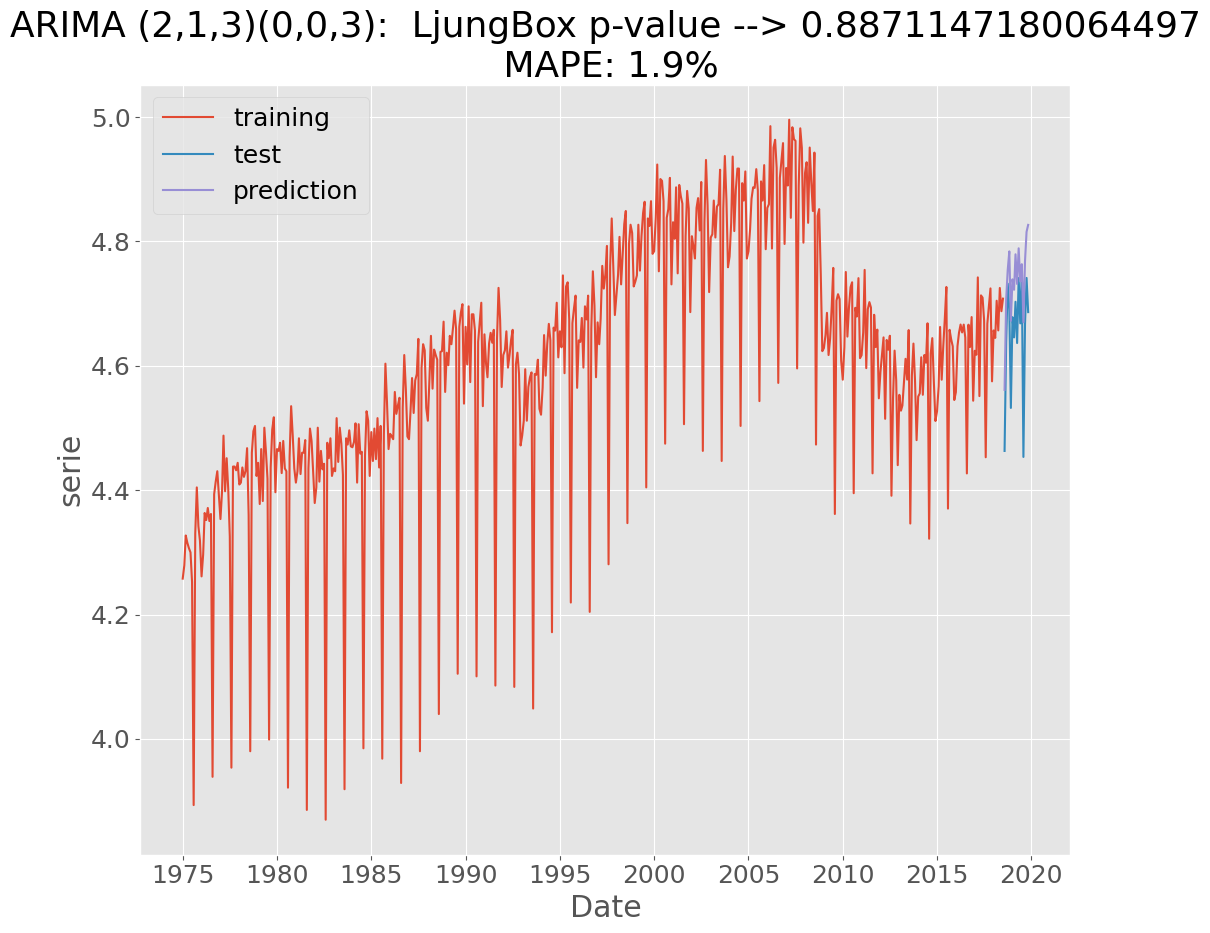

0.8871147180064497


In [80]:
# Evaluación del modelo (eval_model)
eval_model(model_fit, train, test, 'ARIMA (2,1,3)(0,0,3)')

¿Es tu modelo válido para la predicción en términos de adecuación residual? En caso contrario, juega con los órdenes para obtener un modelo que satisfaga el test de residuos. ¿Es este modelo aceptable mejor que el suavizado en términos de capacidad de predicción en el conjunto de test? 

**Respuesta**: En terminos de adecuación residual es mucho mejor que el suavizado siendo este modelo válido en estos terminos.
No es mejor que el suavizado en términos de predicción en ninguna de sus versiones igualmente el error es mínimo porque es inferior a un 2%, hace una estimación cercana a la realidad. 

## Pregunta 10

Indica el código necesario para leer el archivo **"clientes_cluster.csv"** y mostrar sus primeros registros. 

In [81]:
# Lectura clientes_cluster
cluster= pd.read_csv(r'C:\Users\luissinho1999\Downloads\clientes_cluster.csv')
print(cluster.head())


   CustomerID  Gender   Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  19.0                15.0                    39.0
1           2    Male  21.0                15.0                     NaN
2           3  Female  20.0                16.0                     6.0
3           4  Female  23.0                16.0                     NaN
4           5  Female  31.0                 NaN                    40.0


## Pregunta 11

Evalúa la incidencia de valores perdidos por variable e imputa el archivo mediante el método multivariante basado en el algoritmo Iterativo por cadenas de Markov (IterativeImputer), generando un nuevo archivo completo **"clientes_imputed"** del que se mostrará la información para comprobar que efectivamente todos los registros contienen valores válidos.

In [82]:
#Incidencia de missings por variable
missing_info = cluster.isnull().sum()
print("Incidencia de valores perdidos por variable:")
print(missing_info)
print(cluster['Gender'].to_string(index=False))

Incidencia de valores perdidos por variable:
CustomerID                 0
Gender                    15
Age                       13
Annual Income (k$)         9
Spending Score (1-100)    18
dtype: int64
  Male
  Male
Female
Female
Female
Female
Female
Female
  Male
   NaN
  Male
   NaN
Female
Female
  Male
  Male
Female
  Male
  Male
Female
  Male
  Male
Female
  Male
   NaN
  Male
Female
  Male
Female
Female
  Male
Female
  Male
  Male
Female
Female
Female
Female
Female
Female
Female
  Male
  Male
Female
Female
Female
Female
Female
Female
Female
Female
  Male
Female
  Male
   NaN
  Male
Female
  Male
Female
   NaN
  Male
  Male
Female
   NaN
  Male
  Male
Female
Female
  Male
Female
  Male
Female
Female
   NaN
  Male
  Male
Female
  Male
Female
Female
  Male
  Male
  Male
Female
   NaN
  Male
Female
Female
Female
Female
Female
  Male
  Male
Female
Female
  Male
Female
Female
   NaN
  Male
Female
Female
  Male
  Male
  Male
Female
Female
  Male
  Male
  Male
  Male
Female
Female
  Male

**Comentario**: Tenemos que imputar algunos datos, ya que hemos visto que todas las variables tienen entre 9-18 datos perdidos

Antes de proceder con las imputaciones, y para evitar fallos, recodifica *Gender* como una variable dummy (cualquier opción de código es bienvenida) en formato numérico y elimina el ID de cliente de cara al análisis.

In [83]:
# Recodificación de Gender como dummy
clientes_imputed = cluster.copy()



map_dict = {'Male': 0, 'Female': 1} 


clientes_imputed['Gender'] = clientes_imputed['Gender'].map(map_dict).fillna(cluster['Gender'])
clientes_imputed['Gender'] = clientes_imputed['Gender'].astype('Int64')

#Eliminar el ID de cliente
clientes_imputed = clientes_imputed.drop('CustomerID', axis=1)
print(clientes_imputed.info())
print(clientes_imputed['Gender'].to_string(index=False))
print(clientes_imputed['Gender'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  185 non-null    Int64  
 1   Age                     187 non-null    float64
 2   Annual Income (k$)      191 non-null    float64
 3   Spending Score (1-100)  182 non-null    float64
dtypes: Int64(1), float64(3)
memory usage: 6.6 KB
None
   0
   0
   1
   1
   1
   1
   1
   1
   0
<NA>
   0
<NA>
   1
   1
   0
   0
   1
   0
   0
   1
   0
   0
   1
   0
<NA>
   0
   1
   0
   1
   1
   0
   1
   0
   0
   1
   1
   1
   1
   1
   1
   1
   0
   0
   1
   1
   1
   1
   1
   1
   1
   1
   0
   1
   0
<NA>
   0
   1
   0
   1
<NA>
   0
   0
   1
<NA>
   0
   0
   1
   1
   0
   1
   0
   1
   1
<NA>
   0
   0
   1
   0
   1
   1
   0
   0
   0
   1
<NA>
   0
   1
   1
   1
   1
   1
   0
   0
   1
   1
   0
   1
   1
<NA>
   0
   1
   1
   0
   0
   

In [84]:
# Imputación multivariante Iterativa
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(max_iter=10, random_state=0)
clientes_imputed = pd.DataFrame(imputer.fit_transform(clientes_imputed), columns=clientes_imputed.columns)

# Info del archivo imputado
print(clientes_imputed.info())
print(clientes_imputed['Gender'].to_string(index=False))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  200 non-null    float64
 1   Age                     200 non-null    float64
 2   Annual Income (k$)      200 non-null    float64
 3   Spending Score (1-100)  200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
0.000000
0.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
0.000000
0.571211
0.000000
0.578152
1.000000
1.000000
0.000000
0.000000
1.000000
0.000000
0.000000
1.000000
0.000000
0.000000
1.000000
0.000000
0.559955
0.000000
1.000000
0.000000
1.000000
1.000000
0.000000
1.000000
0.000000
0.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
0.000000
0.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
1.000000
0.000000
1.000000
0.000000
0.554445
0.000000
1.000000
0.000000
1.000000
0.

¿Observas alguna cosa extraña en las imputaciones? En caso afirmativo, ¿cuál es tu conclusión?

**Respuesta:** Aunque haya cambiado el tipo de dato a dummy, a la hora de imputar me da valores decimales. Algo imposible ya que es una variable categórica.

Como posibilidad para revertir el extraño comportamiento, redondea la variable categórica y conviértela otra vez en entera.

In [85]:
# Redondear la variable categórica
clientes_imputed['Gender'] = clientes_imputed['Gender'].round()

# Convertir la variable categórica a entera
clientes_imputed['Gender'] = clientes_imputed['Gender'].astype('int')





print(clientes_imputed['Gender'].value_counts())
print(clientes_imputed.info())
print(clientes_imputed['Gender'].to_string(index=False))



Gender
1    117
0     83
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  200 non-null    int32  
 1   Age                     200 non-null    float64
 2   Annual Income (k$)      200 non-null    float64
 3   Spending Score (1-100)  200 non-null    float64
dtypes: float64(3), int32(1)
memory usage: 5.6 KB
None
0
0
1
1
1
1
1
1
0
1
0
1
1
1
0
0
1
0
0
1
0
0
1
0
1
0
1
0
1
1
0
1
0
0
1
1
1
1
1
1
1
0
0
1
1
1
1
1
1
1
1
0
1
0
1
0
1
0
1
1
0
0
1
1
0
0
1
1
0
1
0
1
1
1
0
0
1
0
1
1
0
0
0
1
1
0
1
1
1
1
1
0
0
1
1
0
1
1
1
0
1
1
0
0
0
1
1
0
0
0
0
1
1
0
1
1
1
1
1
1
0
1
1
0
1
1
0
0
0
0
1
0
1
1
0
1
1
0
0
1
1
0
1
1
0
0
0
1
1
0
0
0
1
1
1
1
0
1
0
1
1
1
0
1
0
1
1
1
1
1
0
0
0
0
1
1
0
0
0
0
1
1
0
1
1
0
1
0
1
1
1
1
0
1
1
1
1
0
0
0


## Pregunta 12

Explora los métodos de clustering jerárquico para formar grupos de clientes similares en cuanto a su comportamiento en estas 4 variables disponibles y presenta sus dendogramas.

Vale, pero antes de nada, ¿consideras necesario realizar el escalado de los datos previo al clustering? ¿por qué?

**Respuesta:** Si, porque el modelo contiene años y dinero y no están en la misma escala.


ward :	0.01s


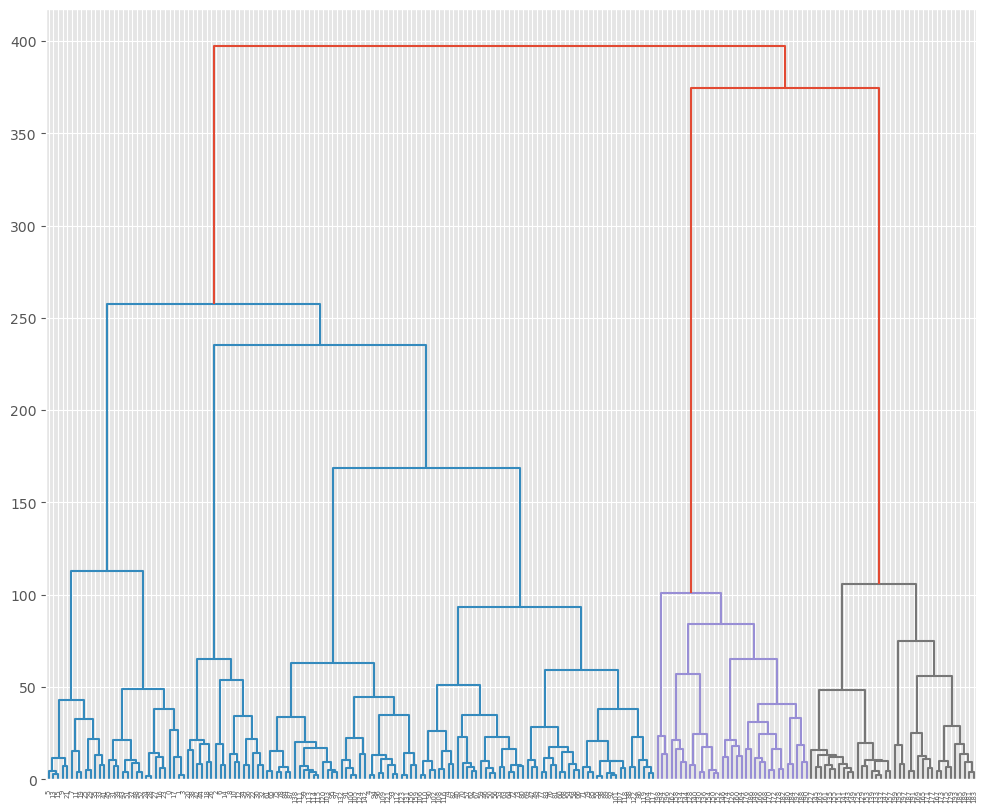

average :	0.01s


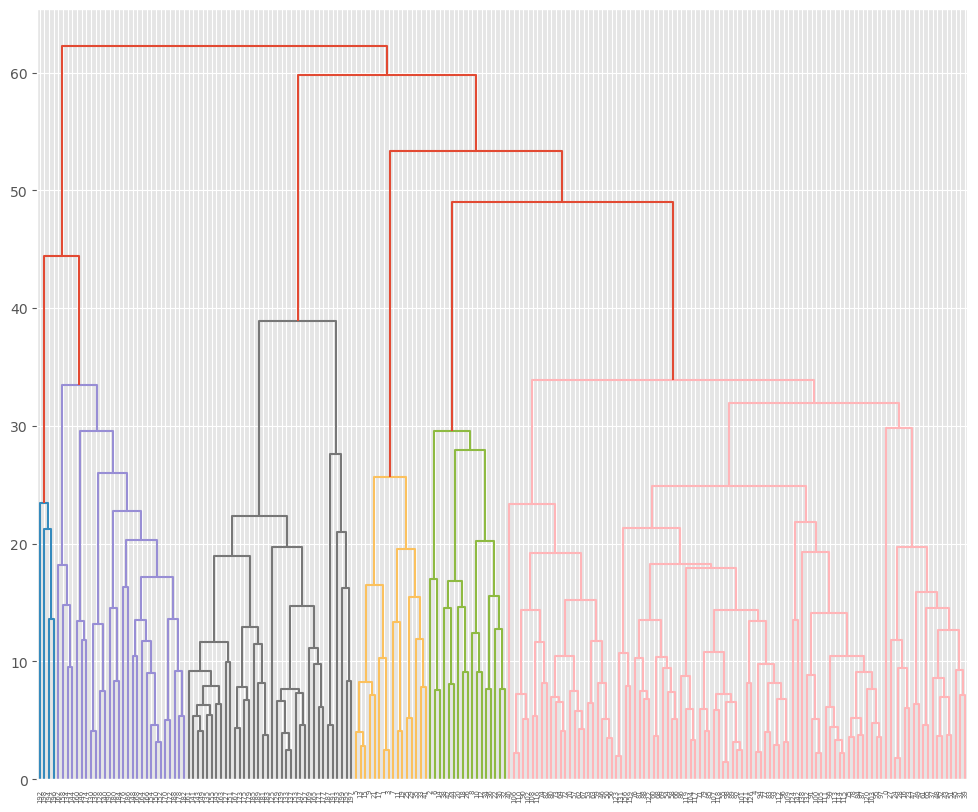

complete :	0.01s


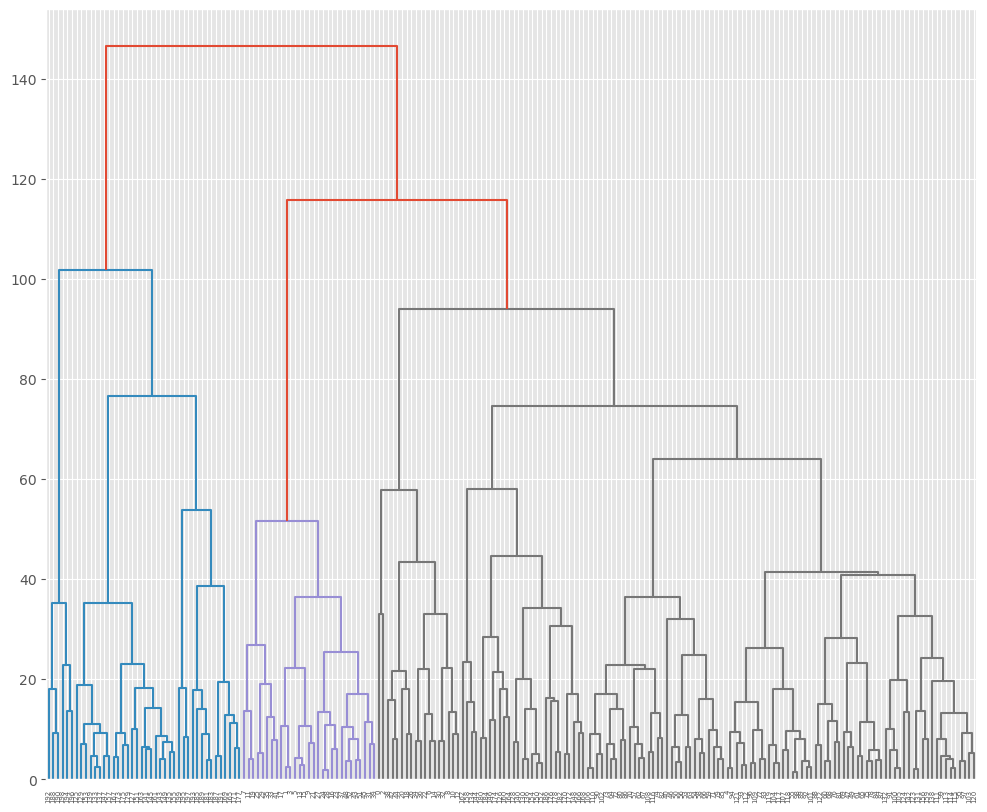

single :	0.00s


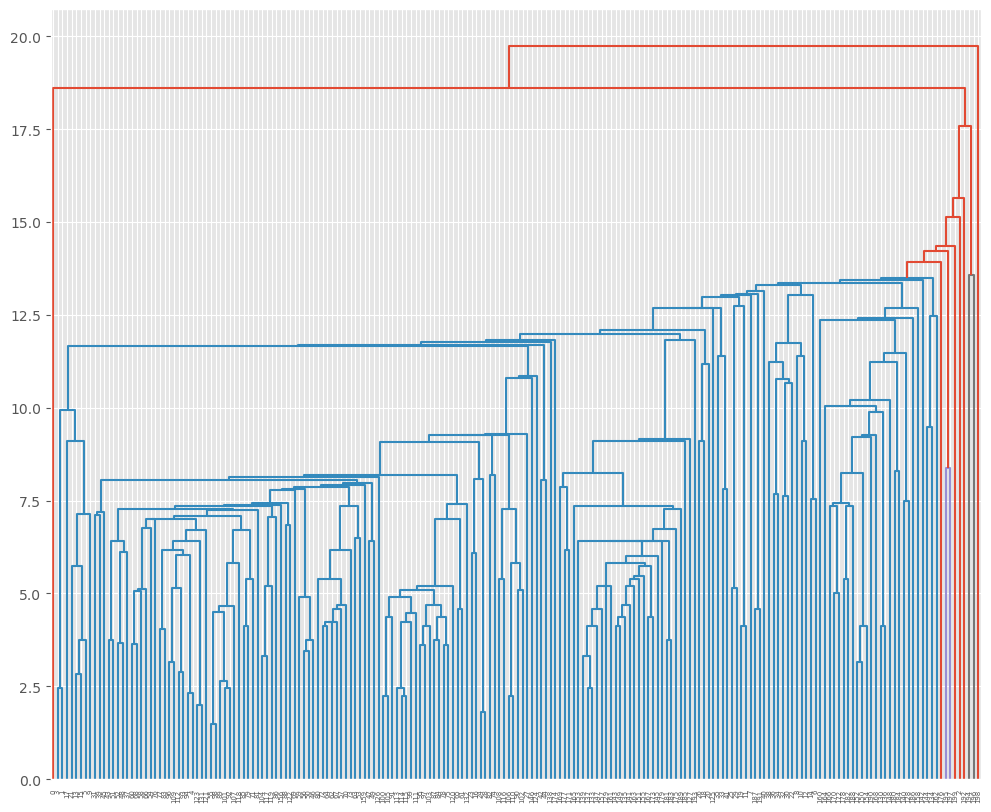

In [86]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (12,10)

# Preprocesado y modelado
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score,silhouette_samples

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')
# Clustering jerárquico bucle de dendogramas
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from time import time

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import numpy as np
import matplotlib.pyplot as plt
from time import time

def plot_dendogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1 
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)

    # Plot
    dendrogram(linkage_matrix, **kwargs)
    plt.show()


X_scaled = clientes_imputed[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

for linkage in ("ward", "average", "complete", "single"):
    clustering = AgglomerativeClustering(linkage=linkage, n_clusters=None, distance_threshold=0)
    t0 = time()
    clustering.fit(X_scaled)
    print("%s :\t%.2fs" % (linkage, time() - t0))

    plt.clf()
    plot_dendogram(clustering)
   
plt.show()



¿Cuál es el método de linkage más adecuado a la vista de los dendogramas? ¿Cuantos grupos de clientes formarías en base a las alturas del dendograma del linkage escogido?

**Respuesta**: El que a simple vista me parece mejor es el complete, y formaría 5 grupos de clientes

## Pregunta 13

Explora el clustering K-means con distinto número de grupos y decide cuantos el número de clusters óptimo para la solución según este método. Comenta las métricas de evaluación.

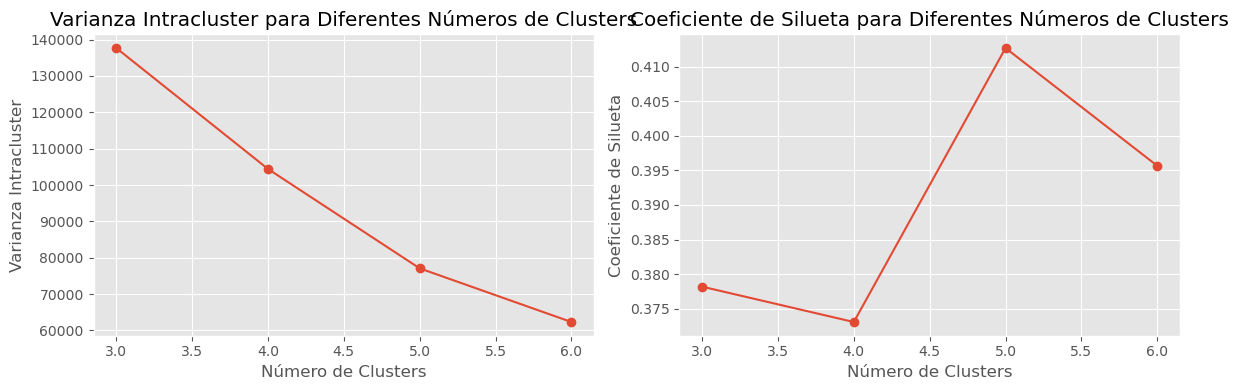

In [88]:
# Clustering k-means evaluación número clusters
# Modelo
# ==============================================================================
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Definir números de clusters
num_clusters = [3, 4, 5, 6]

# Inicializar listas para almacenar la varianza y el coeficiente de silueta
inertia_scores = []
silhouette_scores = []

# Iterar sobre los diferentes números de clusters
for num in num_clusters:
    # Crear y ajustar el modelo KMeans
    modelo_kmeans = KMeans(n_clusters=num, n_init=25, random_state=123)
    modelo_kmeans.fit(X_scaled)
    
    # Calcular la varianza intracluster
    inertia_scores.append(modelo_kmeans.inertia_)

    # Calcular el coeficiente de silueta
    etiquetas = modelo_kmeans.labels_
    silueta = silhouette_score(X_scaled, etiquetas)
    silhouette_scores.append(silueta)

# Graficar la varianza intracluster
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(num_clusters, inertia_scores, marker='o')
plt.title('Varianza Intracluster para Diferentes Números de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Varianza Intracluster')

# Graficar el coeficiente de silueta
plt.subplot(1, 2, 2)
plt.plot(num_clusters, silhouette_scores, marker='o')
plt.title('Coeficiente de Silueta para Diferentes Números de Clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silueta')

plt.tight_layout()
plt.show()


**Respuesta**: 
Es obvio que cuantos más grupos de clientes, menor varianza y se ajusta mejor. Pero a partir de cierta cantidad de grupos, es contraproducente, ya que la varianza se reduce en poca cantidad. Teniendo en cuenta el principio de parsimonia y viendo la gráfica, vemos que el óptimo son 5 grupos, ya que al añadir un sexto grupo la varianza decrece mucho menos. Por otra parte, nuestro coeficiente de silueta óptimo está en 5 grupos, coincidiendo con la varianza y mi hipótesis en los modelos jerarquizados.

Ajusta el clustering K-means con el núemero de grupos seleccionado y genera una nueva variable en el conjunto de datos imputado llamada *'Cluster'* que recoja el número de grupo asignado a cada registro. El tipo de la variable debe ser entero (int).  

In [89]:
# Ajuste de k-means
n_clusters = 5
modelo_kmeans = KMeans(n_clusters=n_clusters, n_init=25, random_state=123)
modelo_kmeans.fit(X=X_scaled)

# Creación de variable cluster
clientes_imputed['Cluster'] = modelo_kmeans.labels_.astype(int)
print(clientes_imputed[['Cluster']])


     Cluster
0          4
1          4
2          2
3          4
4          1
..       ...
195        3
196        0
197        3
198        0
199        3

[200 rows x 1 columns]


Extrae los centroides de los grupos y comenta las principales características de cada grupo formado. 

In [90]:
# Centroides
# Extraer los centroides de los grupos
centroides = modelo_kmeans.cluster_centers_

# Crear un DataFrame para visualizar los centroides
centroides_df = pd.DataFrame(centroides, columns=X_scaled.columns)
print(centroides)

# Comentar las principales características de cada grupo
for i in range(n_clusters):
    print(f'\nCaracterísticas del Grupo {i + 1} (Cluster {i}):')
    print(centroides_df.iloc[i])



[[41.25910114 88.67378241 18.219316  ]
 [42.66580716 57.19654029 49.02061803]
 [47.83333333 27.5        17.88888889]
 [32.13183599 87.07056925 81.757552  ]
 [26.86352714 28.19354839 68.12591941]]

Características del Grupo 1 (Cluster 0):
Age                       41.259101
Annual Income (k$)        88.673782
Spending Score (1-100)    18.219316
Name: 0, dtype: float64

Características del Grupo 2 (Cluster 1):
Age                       42.665807
Annual Income (k$)        57.196540
Spending Score (1-100)    49.020618
Name: 1, dtype: float64

Características del Grupo 3 (Cluster 2):
Age                       47.833333
Annual Income (k$)        27.500000
Spending Score (1-100)    17.888889
Name: 2, dtype: float64

Características del Grupo 4 (Cluster 3):
Age                       32.131836
Annual Income (k$)        87.070569
Spending Score (1-100)    81.757552
Name: 3, dtype: float64

Características del Grupo 5 (Cluster 4):
Age                       26.863527
Annual Income (k$)        28.1

**Comentarios**:
Grupo 1: Personas de mediana edad, ingresos mas altos y bajo gasto.
Grupo 2: Mediana edad, buenos ingresos y balance positivo
Grupo 3: Mas mayores, ingresos y gastos mas bajos.
Grupo 4: Personas jóvenes, ingresos altos y lideran en gasto pero balance positivo.
Grupo 5: Mas jóvenes, bajos ingresos con gasto elevado.

## Pregunta 14

De cara a la proyección de los grupos formados en el espacio de características y dado que estamos en R4. Nos planteamos reducir la dimensionalidad a 2 para poder interpretar con mayor claridad mediante un bonito biplot. 

Para llevar a cabo esta tarea, necesitaremos ajustar un PCA con 2 dimensiones a los **datos de entrada al clustering** que hemos generado, es decir, tal vez utilizamos el conjunto de datos escalado si lo consideramos necesario. Mostraremos las cargas de las variables en las componentes y haremos una pequeña interpretación inicial de las 2 componentes.


[pca] >Extracting column labels from dataframe.
[pca] >Extracting row labels from dataframe.
[pca] >Normalizing input data per feature (zero mean and unit variance)..
[pca] >The PCA reduction is performed on the [3] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


,Age,Annual Income (k$),Spending Score (1-100)
PC1,0.701669,-0.097234,-0.705838
PC2,0.111806,0.993398,-0.025703


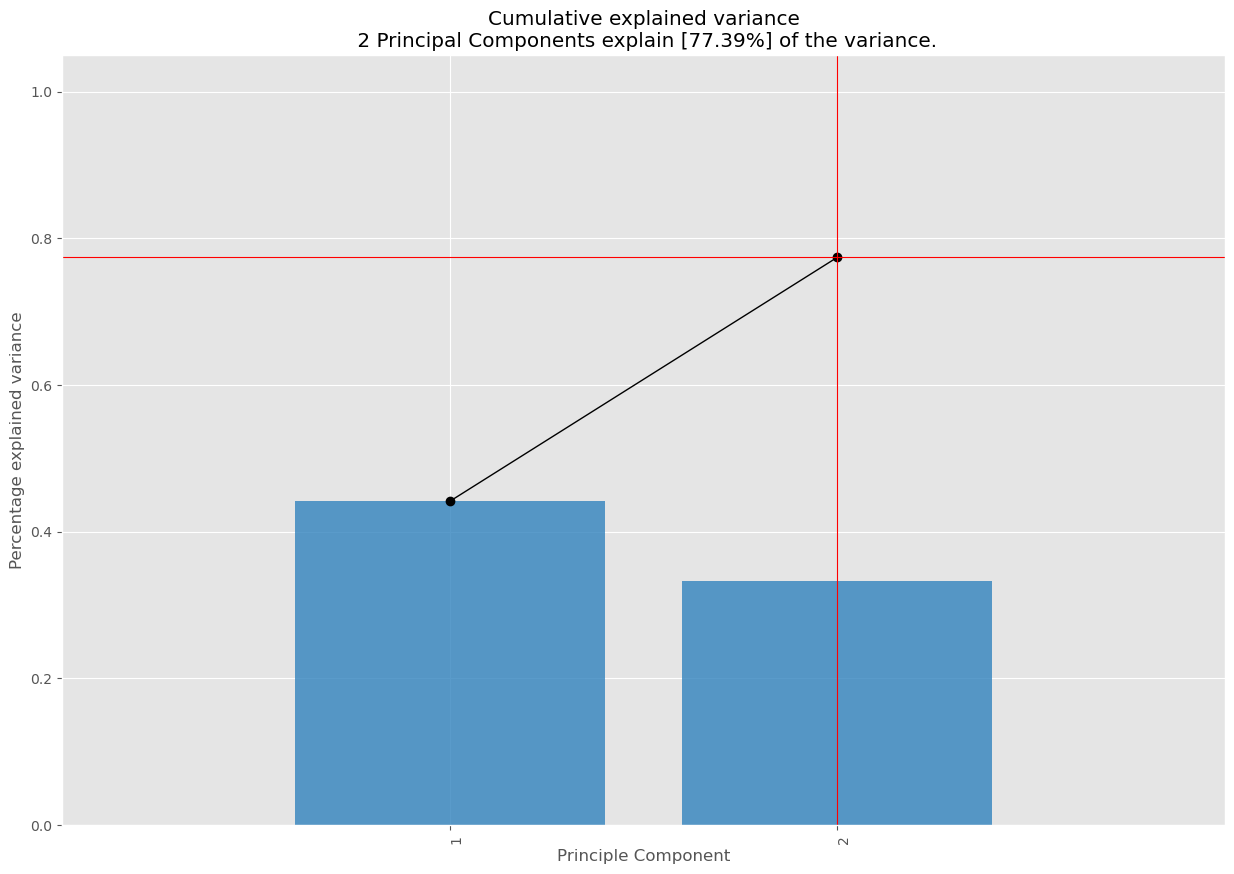

In [91]:
# Ajuste PCA 2 dimensiones
from pca import pca
# Ajustar PCA con 2 componentes
pcaModel = pca(normalize=True,n_components=2)
results = pcaModel.fit_transform(clientes_imputed.iloc[:, 1:4])

pcaModel.plot()

# Análisis de cargas
pcaModel.results['loadings']

**Interpretación inicial**:La PC1 muestra una relación fuertemente negativa con el gasto y una relación positiva con la edad. Indica que a medida que la edad aumenta y el gasto disminuye, PC1 tiende a aumentar. La PC2 presenta una fuerte relación positiva con el ingreso y una relación débil con la edad y el gasto. Esto sugiere que a medida que el ingreso aumenta, PC2 tiende a ser mayor

Ahora generamos y mostramos el biplot para interpretar con mayor seguridad las componentes. 

[scatterd] >INFO> Create scatterplot


[pca] >Plot PC1 vs PC2 with loadings.


(<Figure size 2500x1500 with 1 Axes>,
 <Axes: title={'center': '2 Principal Components explain [77.39%] of the variance'}, xlabel='PC1 (44.1% expl.var)', ylabel='PC2 (33.2% expl.var)'>)

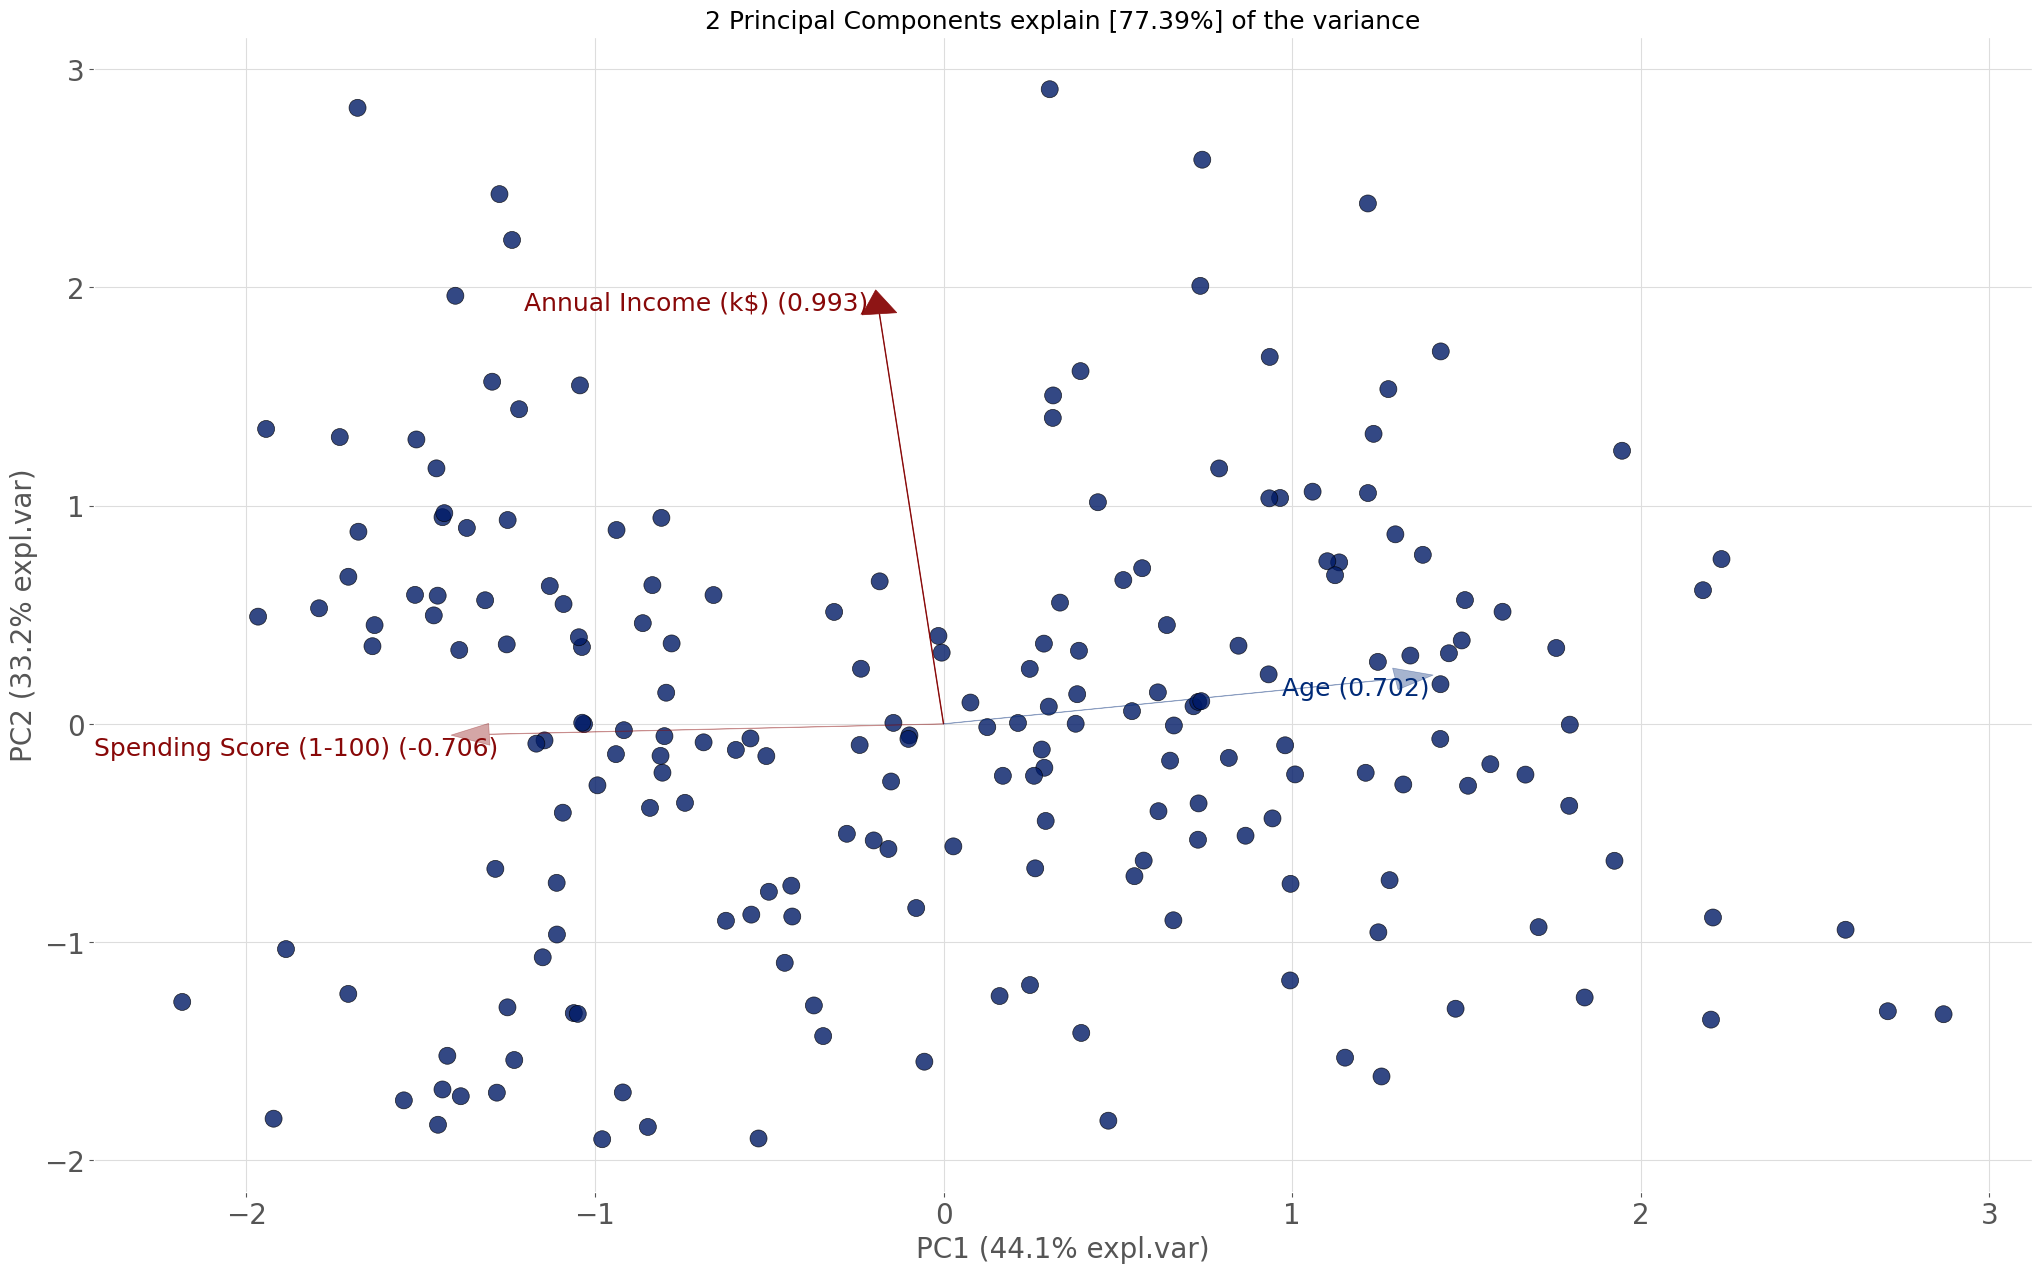

In [92]:
# Biplot
pcaModel.biplot(legend=False)

**Interpretación gráfica**: La interpretación gráfica corobora mi interpretación inicial.

Ahora que sabemos lo que represanta cada componente en el espacio original de las variables, necesitamos un conjunto de datos que contenga las columnas *PC1*,*PC2* y *Cluster* para realizar la representación de los clientes por grupos propuestos e interpretar las características de los grupos en el espacio de las componentes. 

In [93]:
# Creación dataset dimensión reducida

pcaModel.results['PC']
clientes_pca = pcaModel.results['PC'].join(clientes_imputed['Cluster'])
clientes_pca
# Representación de grupos en espacio de componentes
fig = px.scatter(clientes_pca, x='PC1',y='PC2', color='Cluster')
fig.show()

**Interpretación de biplot**: Se diferencia en el biplot los 5 tipos de clientes, vemos que hay un tipo de clientes en cada esquina, y el grupo 2 (cluster 1) en unas posiciones mas centrales. Parece que los clusters se han situado correctamente con posiciones bastante cerca de sus centroides. Pero a simple vista veo que un punto situado PC1= 0,28 PC2 0,11 y otro mas situado a la izquierda pertenecientes a cluster 0, estan rodeados de puntos del cluster situado en el centro. Vemos que hay mínimo 2 errores en nuestro modelo.